# Korrelation Psychotherapie & Raumstruktur – Nordbayern

INKAR Spalten:
['Kennziffer', 'Raumeinheit', 'Aggregat', 'Bodenfläche gesamt qkm', 'Bevölkerung gesamt', 'Bevölkerung männlich', 'Bevölkerung weiblich', 'Erwerbsfähige Bevölkerung (15 bis unter 65 Jahre)', 'Sozialversicherungspflichtig Beschäftigte am Arbeitsort', 'Sozialversicherungspflichtig Beschäftigte am Wohnort', 'Einwohner von 18 bis unter 25 Jahren', 'Einwohner von 25 bis unter 30 Jahren', 'Einwohner von 30 bis unter 50 Jahren', 'Einwohner von 50 bis unter 65 Jahren', 'Bevölkerung', 'Einwohnerdichte', 'Einwohner je Arzt', 'Allgemeinärzte', 'Ärzte', 'Ländlichkeit', 'Bevölkerung in Mittelzentren', 'Bevölkerung in Oberzentren']

Psychotherapeuten Spalten:
['AG', 'AG_NAME', 'REG_BEZIRK', 'EBENE', 'EBENE_ID', 'AGS', 'EBENE_NAME', 'Einwohner', 'Versorgungsgrad', 'Kassensitze', 'Kassensitz/100.000Einwohner', 'Personen', 'Ärztliche Psychotherapeuten', 'Psychologische Psychotherapeuten', 'Kinder- u. Jugendlichenpsychotherapeuten', 'weiblich', 'weiblich anteil', 'männlich', 'männlich ant

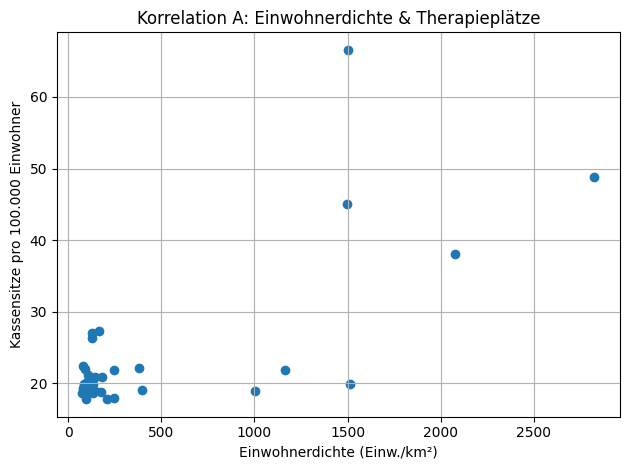

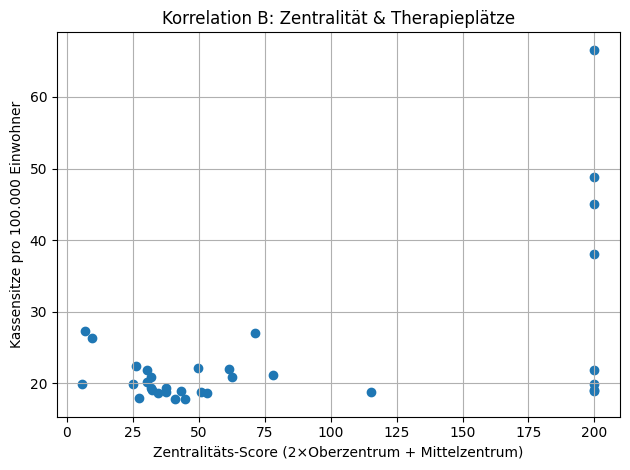


 Exportiert: merged_nordbayern.csv


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# ------------------------------------------------------------
# 1) Dateipfade (Notebook liegt im Ordner /notebooks)
# ------------------------------------------------------------
INKAR_CSV = "../data/20251215.csv"
PSY_CSV   = "../data/Psychotherapeuten.csv"

# ------------------------------------------------------------
# 2) Hilfsfunktionen
# ------------------------------------------------------------

def to_numeric(series: pd.Series) -> pd.Series:
    """
    Wandelt deutsche Zahlenformate robust um:
    '1.234,56' -> 1234.56
    """
    return pd.to_numeric(
        series.astype(str)
              .str.replace(".", "", regex=False)
              .str.replace(",", ".", regex=False),
        errors="coerce"
    )

def to_ags_from_kennziffer(x):
    """
    INKAR-Kennziffer -> AGS (5-stellig, z.B. 9471 -> 09471)
    """
    try:
        if pd.isna(x):
            return None
        return str(int(float(x))).zfill(5)
    except Exception:
        return None

# ------------------------------------------------------------
# 3) CSV-Dateien laden
# ------------------------------------------------------------
inkar = pd.read_csv(INKAR_CSV, sep=";", encoding="utf-8-sig")
psy   = pd.read_csv(PSY_CSV, sep=";", encoding="utf-8-sig")

# Spalten säubern (wichtig!)
inkar.columns = inkar.columns.str.strip()
psy.columns   = psy.columns.str.strip()

print("INKAR Spalten:")
print(inkar.columns.tolist())
print("\nPsychotherapeuten Spalten:")
print(psy.columns.tolist())

# ------------------------------------------------------------
# 4) AGS-Schlüssel erzeugen
# ------------------------------------------------------------
inkar["AGS"] = inkar["Kennziffer"].map(to_ags_from_kennziffer)

# Nur Planungsbereiche (PB) verwenden
psy = psy[psy["EBENE"] == "PB"].copy()

psy["AGS"] = (
    psy["AGS"].astype(str)
              .str.replace(r"\.0$", "", regex=True)
              .str.replace(r"\D", "", regex=True)
              .str.zfill(5)
)

# ------------------------------------------------------------
# 5) Tabellen zusammenführen
# ------------------------------------------------------------
df = inkar.merge(psy, on="AGS", how="inner", suffixes=("_inkar", "_psy"))

print("\nGemergte Zeilen:", len(df))
print(df[["AGS", "Raumeinheit", "EBENE_NAME"]].head())

if df.empty:
    raise ValueError(" Merge leer – AGS stimmt nicht überein.")

# ------------------------------------------------------------
# 6) Analysevariablen vorbereiten
# ------------------------------------------------------------

# X für Korrelation A
df["einwohnerdichte"] = to_numeric(df["Einwohnerdichte"])

# Zentralität für Korrelation B
df["ober_pct"]   = to_numeric(df["Bevölkerung in Oberzentren"])
df["mittel_pct"] = to_numeric(df["Bevölkerung in Mittelzentren"])

# Zentralitäts-Score (Interpretierbar!)
df["zentral_score"] = 2 * df["ober_pct"] + 1 * df["mittel_pct"]

# Y-Variablen (Therapieversorgung)
df["kassensitze"]      = to_numeric(df["Kassensitze"])
df["kass_100k"]        = to_numeric(df["Kassensitz/100.000Einwohner"])
df["versorgungsgrad"]  = to_numeric(df["Versorgungsgrad"])

# ------------------------------------------------------------
# 7) Korrelationen berechnen
# ------------------------------------------------------------

def run_correlation(x, y, label):
    tmp = df[[x, y]].dropna()
    r, p = pearsonr(tmp[x], tmp[y])
    print(f"\n{label}")
    print(f"N = {len(tmp)}")
    print(f"r = {r:.3f}")
    print(f"p = {p:.6f}")
    return tmp, r, p

# Empfehlung: Kassensitze pro 100.000 Einwohner
tmpA, rA, pA = run_correlation(
    "einwohnerdichte",
    "kass_100k",
    "KORRELATION A: Einwohnerdichte ↔ Kassensitze pro 100.000"
)

tmpB, rB, pB = run_correlation(
    "zentral_score",
    "kass_100k",
    "KORRELATION B: Zentralität ↔ Kassensitze pro 100.000"
)

# ------------------------------------------------------------
# 8) Visualisierung
# ------------------------------------------------------------

plt.figure()
plt.scatter(tmpA["einwohnerdichte"], tmpA["kass_100k"])
plt.xlabel("Einwohnerdichte (Einw./km²)")
plt.ylabel("Kassensitze pro 100.000 Einwohner")
plt.title("Korrelation A: Einwohnerdichte & Therapieplätze")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure()
plt.scatter(tmpB["zentral_score"], tmpB["kass_100k"])
plt.xlabel("Zentralitäts-Score (2×Oberzentrum + Mittelzentrum)")
plt.ylabel("Kassensitze pro 100.000 Einwohner")
plt.title("Korrelation B: Zentralität & Therapieplätze")
plt.grid(True)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 9) Export für Dokumentation / Abgabe
# ------------------------------------------------------------
df[[
    "AGS",
    "Raumeinheit",
    "EBENE_NAME",
    "einwohnerdichte",
    "ober_pct",
    "mittel_pct",
    "zentral_score",
    "kassensitze",
    "kass_100k",
    "versorgungsgrad"
]].to_csv("../data/merged_nordbayern.csv", index=False)

print("\n Exportiert: merged_nordbayern.csv")

# Erklärung 
## A
33 Regionen in Nordbayern (Kreise & kreisfreie Städte) zusammengeführt und zwei Zusammenhänge getestet:
	•	Korrelation A:
Einwohnerdichte ↔ Kassensitze pro 100.000 Einwohner
	•	Korrelation B:
Zentralität des Raums ↔ Kassensitze pro 100.000 Einwohner

## Richtung
	•	positiv (r > 0)
Je höher die Einwohnerdichte, desto mehr Psychotherapie-Kassensitze pro 100.000 Einwohner

## Stärke
	•	r = 0.719
starker Zusammenhang
(alles über 0.6 gilt in Sozialwissenschaften als stark)

## Signifikanz
	•	p = 0.000002 (sehr viel kleiner als 0.05)
Das Ergebnis ist hoch signifikant
Die Wahrscheinlichkeit, dass dieser Zusammenhang zufällig entstanden ist, liegt bei 0,0002 %


# Interpretation 
„Zwischen der Einwohnerdichte und der Anzahl der Psychotherapie-Kassensitze pro 100.000 Einwohner besteht in Nordbayern ein starker positiver Zusammenhang (r = 0,72; p < 0,001). Dichter besiedelte Regionen verfügen systematisch über mehr ambulante Therapieplätze als dünn besiedelte Landkreise.“

--> Das erklärt, warum Städte deutlich besser versorgt sind als ländliche Räume.

## B

## Richtung
	•	positiv
Je zentraler ein Ort (Ober- oder Mittelzentrum), desto höher die Dichte an Therapieplätzen

## Stärke
	•	r = 0.545
mittlerer bis deutlicher Zusammenhang

## Signifikanz
	•	p = 0.001
Ebenfalls statistisch signifikant

# Interpretation 

Auch die Zentralität einer Region steht in einem signifikanten Zusammenhang mit der ambulanten psychotherapeutischen Versorgung (r = 0,55; p < 0,01). Ober- und Mittelzentren weisen im Durchschnitt mehr Kassensitze pro Einwohner auf als periphere, ländliche Räume.


Korrelation   |  Erklärung
A (0.719)     |  Einwohnerdichte ist ein sehr direkter Standortfaktor
B (0.545)     |  Zentralität ist gröber (Kategorie-Variable)


## These 1 – Bewiesen

Therapieplätze konzentrieren sich in dicht besiedelten Regionen.

## These 2 – Bewiesen

Zentrale Orte sind systematisch besser versorgt als ländliche Räume.

## Wichtiger Schluss (Brücke zum Zeitungsartikel)

Die formale „Überversorgung“ in Bayern entsteht durch die starke räumliche Konzentration der Kassensitze – nicht durch eine gleichmäßige Versorgung

Die statistischen Ergebnisse zeigen, dass die Bedarfsplanung die räumliche Nachfrage nur unzureichend abbildet. Obwohl zentrale und dicht besiedelte Regionen formal überversorgt sind, bleiben ländliche Räume strukturell benachteiligt.